# Pipeline Walkthrough — molecule → graph → prediction

The pipeline boundary (CLAUDE.md §3) is physical: **`data/` builds the graph (deterministic,
no learning); `model/` consumes it (all learning).** The graph is the interface. Absolute
coordinates never enter the model as node features — geometry enters only through edges.

## Stage 1 — parse geometry from a SIESTA `.fdf` (data code)

In [1]:
import demo_utils  # noqa: F401 — puts the repo root on sys.path
from pathlib import Path
import tempfile, numpy as np
from data.parse_siesta import parse_fdf

fdf = '''NumberOfAtoms 5
%block ChemicalSpeciesLabel
 1 6 C
 2 1 H
%endblock ChemicalSpeciesLabel
AtomicCoordinatesFormat Ang
%block AtomicCoordinatesAndAtomicSpecies
 0.000  0.000  0.000  1
 0.629  0.629  0.629  2
 0.629 -0.629 -0.629  2
-0.629  0.629 -0.629  2
-0.629 -0.629  0.629  2
%endblock AtomicCoordinatesAndAtomicSpecies
'''
p = Path(tempfile.gettempdir()) / "demo.fdf"; p.write_text(fdf)
z, pos = parse_fdf(p)
print("Z  :", z)
print("pos:\n", pos)

Z  : [6 1 1 1 1]
pos:
 [[ 0.     0.     0.   ]
 [ 0.629  0.629  0.629]
 [ 0.629 -0.629 -0.629]
 [-0.629  0.629 -0.629]
 [-0.629 -0.629  0.629]]


## Stage 2 — build the graph (data code)

Fully connected, distances in Å + relative vectors. The **full pairwise distance set is the
geometry** (§3): it fixes the shape up to rotation/translation/reflection. The heatmap below is
that distance matrix.

edge_index shape: (2, 20) (all ordered pairs i≠j)


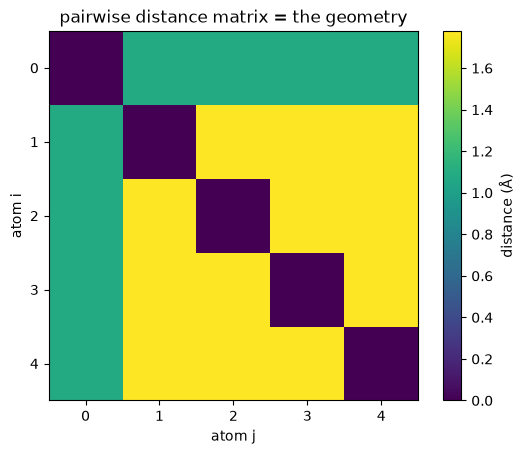

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from data.graph import build_graph

g = build_graph(pos)
print("edge_index shape:", g["edge_index"].shape, "(all ordered pairs i≠j)")

N = len(z); D = np.zeros((N, N))
i, j = g["edge_index"]; D[i, j] = g["distances"]
plt.imshow(D, cmap="viridis"); plt.colorbar(label="distance (Å)")
plt.title("pairwise distance matrix = the geometry"); plt.xlabel("atom j"); plt.ylabel("atom i")
plt.show()

## Stage 3 — the model (all learning)

Element embedding seeds the invariant scalar track `h`; positions seed the equivariant track
`x`. The EGNN backbone updates both; the heads read out an invariant energy and an equivariant
Wannier center set.

In [3]:
import jax
from model.embeddings import ElementEmbedding

emb = ElementEmbedding(n_elements=100, hidden_dim=32)
h = emb.apply(emb.init(jax.random.PRNGKey(0), z), z)
print("element embedding h:", h.shape, "(invariant scalar track)")

element embedding h: (5, 32) (invariant scalar track)


In [4]:
from demo_utils import init_model

model, params, apply = init_model()
out = apply(params, z, pos)
print("energy (invariant scalar):", float(out["energy"]), "eV")
print("wannier centers  [spin, slot, 3]:", np.asarray(out["wannier"]["centers"]).shape)
print("wannier radii    [spin, slot]   :", np.asarray(out["wannier"]["radii"]).shape)
print("wannier presence [spin, slot]   :", np.round(np.asarray(out["wannier"]["presence"]), 2))

energy (invariant scalar): 1.6082441806793213 eV
wannier centers  [spin, slot, 3]: (2, 8, 3)
wannier radii    [spin, slot]   : (2, 8)
wannier presence [spin, slot]   : [[0.66 0.2  0.18 0.57 0.73 0.45 0.69 0.23]
 [0.86 0.11 0.34 0.87 0.42 0.18 0.87 0.31]]


### Takeaway

`data/` turned a molecule into a graph by a fixed rule; `model/` turned the graph into
predictions with all the learned weights. Neither reaches across the boundary — the model never
parses files, and it never sees an absolute coordinate as a feature.